# Finviz como Juego de Atención

**Marco**: el universo Finviz es un mecanismo de coordinación público. Cada categoría es un tablero compartido. La hipótesis es que la dinámica colectiva — quién lidera, cuánto tiempo lleva, cuántas categorías lo ven — contiene señal sobre el comportamiento futuro del precio.

**Limitación conocida**: Finviz Top Gainers muestra siempre 6-7 tickers (crowd_size constante). El diferenciador es la **posición dentro del crowd**, no el tamaño del crowd.

**Split**: Mar 24–Apr 9 = exploración | Apr 10–Apr 17 = validación  
**Criterio**: conclusión válida solo si EV > +1% neto y n ≥ 20 en validación

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import sqlite3, pytz, dateutil.parser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from pathlib import Path
from helpers.forward_returns import BarsIndex
from helpers.data_loader import load_market_bars

DB_PROD  = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'
DB_BURST = Path('..') / 'burst_intraday_cache.db'
ET       = pytz.timezone('America/New_York')

EXPLORE_DAYS  = ['2026-03-24','2026-03-25','2026-03-26','2026-03-27','2026-03-30',
                 '2026-04-02','2026-04-06','2026-04-07','2026-04-08','2026-04-09']
VALIDATE_DAYS = ['2026-04-10','2026-04-13','2026-04-14','2026-04-15','2026-04-16','2026-04-17']
ALL_DAYS      = EXPLORE_DAYS + VALIDATE_DAYS
SLIPPAGE      = 0.005

def parse_ts(ts):
    dt = dateutil.parser.parse(ts)
    return dt.astimezone(ET) if dt.tzinfo else ET.localize(dt)

print('Config OK')

Config OK


## 1. Carga de datos

In [2]:
with sqlite3.connect(DB_PROD) as conn:
    raw = pd.read_sql(
        'SELECT ticker, timestamp, price, change_pct, volume, category FROM snapshots ORDER BY timestamp',
        conn
    )

raw['ts']      = raw['timestamp'].apply(parse_ts)
raw['day']     = raw['ts'].dt.strftime('%Y-%m-%d')
raw['mso']     = (raw['ts'].dt.hour - 9) * 60 + raw['ts'].dt.minute - 30
raw['chg_f']   = pd.to_numeric(raw['change_pct'].str.replace('%','').str.strip(), errors='coerce')
raw['price_f'] = pd.to_numeric(raw['price'].str.replace('$','').str.replace(',',''), errors='coerce')
raw = raw[raw['day'].isin(ALL_DAYS)].reset_index(drop=True)

bars = load_market_bars()
with sqlite3.connect(DB_BURST) as cb:
    mb_b = pd.read_sql(
        "SELECT symbol AS ticker, date||'T'||dt AS bar_time, open, high, low, close, volume FROM bars", cb
    )
mb_b['bar_ts'] = pd.to_datetime(mb_b['bar_time']).dt.tz_localize(ET, ambiguous='NaT', nonexistent='NaT')
mb_b['date']   = mb_b['bar_ts'].dt.strftime('%Y-%m-%d')
bars = pd.concat([bars, mb_b], ignore_index=True).drop_duplicates(subset=['ticker','bar_ts'])
bars_idx = BarsIndex(bars)

print(f'Snapshots: {len(raw):,} | categorias: {raw["category"].nunique()} | dias: {raw["day"].nunique()}')
print(f'Bars combinadas: {len(bars):,} | {bars["ticker"].nunique()} tickers')

Snapshots: 26,106 | categorias: 15 | dias: 16
Bars combinadas: 247,832 | 228 tickers


## 2. Universe state — features del tablero

In [3]:
tg = raw[(raw['category'] == 'Top Gainers') & (raw['chg_f'] > 0)].copy()
tg['ts_min'] = tg['ts'].dt.floor('min')

# Finviz muestra siempre 6-7 tickers → crowd_size constante.
# Diferenciadores: rank dentro del crowd y relative strength.
tg['chg_rank']   = tg.groupby(['day','ts_min'])['chg_f'].rank(ascending=False)  # 1=mayor %
tg['crowd_size'] = tg.groupby(['day','ts_min'])['ticker'].transform('count')
crowd_med = tg.groupby(['day','ts_min'])['chg_f'].median().reset_index(name='crowd_median_chg')
tg = tg.merge(crowd_med, on=['day','ts_min'], how='left')
tg['rel_strength'] = tg['chg_f'] / tg['crowd_median_chg']  # >1 = encima mediana
tg = tg.sort_values(['ticker','day','ts_min']).reset_index(drop=True)
tg['appearance_n'] = tg.groupby(['ticker','day']).cumcount() + 1

# attention_score: en cuantas categorias aparece el ticker en ±5min
def att_score(ticker, day, ts):
    lo = ts - pd.Timedelta(minutes=5)
    hi = ts + pd.Timedelta(minutes=5)
    return raw[(raw['ticker']==ticker) & (raw['day']==day) &
               (raw['ts'] >= lo) & (raw['ts'] <= hi)]['category'].nunique()

print(f'TG snapshots: {len(tg):,}')
print(f'crowd_size valores: {sorted(tg["crowd_size"].unique())}  ← siempre 6-7')
print(f'rel_strength p25={tg["rel_strength"].quantile(.25):.2f}  '
      f'p50={tg["rel_strength"].quantile(.5):.2f}  '
      f'p75={tg["rel_strength"].quantile(.75):.2f}')

TG snapshots: 4,016
crowd_size valores: [np.int64(6), np.int64(7), np.int64(12)]  ← siempre 6-7
rel_strength p25=0.77  p50=1.00  p75=1.41


## 3. Eventos con forward returns

In [4]:
def trail_exit(ticker, day, sig_ts, trail_pct=5, horizon=30):
    db = bars_idx.get(ticker, day)
    if db is None: return None
    future = db[db['bar_ts'] > sig_ts].sort_values('bar_ts')
    if future.empty: return None
    ep = float(future.iloc[0]['open'])
    if ep <= 0: return None
    window = future[future['bar_ts'] <= sig_ts + pd.Timedelta(minutes=horizon)]
    if window.empty: return None
    peak = ep
    for _, bar in window.iterrows():
        peak = max(peak, float(bar['high']))
        if float(bar['low']) <= peak * (1 - trail_pct / 100):
            return (peak * (1 - trail_pct/100) - ep) / ep - SLIPPAGE
    return (float(window.iloc[-1]['close']) - ep) / ep - SLIPPAGE

# Una observacion por ticker-dia: primera aparicion en Top Gainers
first_app = tg[tg['appearance_n'] == 1].copy()
rows = []
for _, row in first_app.iterrows():
    ret = trail_exit(row['ticker'], row['day'], row['ts_min'])
    if ret is None: continue
    rows.append({
        'ticker'       : row['ticker'],
        'day'          : row['day'],
        'ts'           : row['ts_min'],
        'mso'          : row['mso'],
        'chg_initial'  : row['chg_f'],
        'price'        : row['price_f'],
        'rel_strength' : row['rel_strength'],
        'chg_rank'     : int(row['chg_rank']),
        'crowd_size'   : int(row['crowd_size']),
        'ret'          : ret,
        'split'        : 'explore' if row['day'] in EXPLORE_DAYS else 'validate',
    })

events = pd.DataFrame(rows)
events['attention_score'] = [
    att_score(r['ticker'], r['day'], r['ts']) for _, r in events.iterrows()
]
max_pers = tg.groupby(['ticker','day'])['appearance_n'].max().reset_index(name='max_persistence')
events = events.merge(max_pers, on=['ticker','day'], how='left')

explore  = events[events['split'] == 'explore']
validate = events[events['split'] == 'validate']

print(f'Eventos: {len(events)}  (explore={len(explore)}, validate={len(validate)})')
print(f'Por dia: {dict(events.groupby("day").size())}')
print()
print('NOTA: exploración n=10 es insuficiente para conclusiones.')
print('Las conclusiones se basan en validación (n=39).')

Eventos: 49  (explore=10, validate=39)


Por dia: {'2026-03-25': np.int64(1), '2026-03-27': np.int64(5), '2026-04-07': np.int64(2), '2026-04-09': np.int64(2), '2026-04-10': np.int64(9), '2026-04-13': np.int64(5), '2026-04-14': np.int64(8), '2026-04-15': np.int64(6), '2026-04-16': np.int64(6), '2026-04-17': np.int64(5)}

NOTA: exploración n=10 es insuficiente para conclusiones.
Las conclusiones se basan en validación (n=39).


## 4. Hipótesis: rank, attention, relative strength, timing

In [5]:
def show(s, label, min_n=5):
    s = s.dropna()
    if len(s) < min_n:
        print(f'  {label:<45} n={len(s):>3}  INSUFICIENTE')
        return
    wr  = (s > 0).mean()
    ev  = s.mean() * 100
    wins = s[s > 0]; loss = s[s < 0]
    pf  = wins.sum() / abs(loss.sum()) if len(loss) > 0 else np.inf
    _, p = scipy_stats.ttest_1samp(s, 0)
    sig = ' ✓' if p < 0.05 else (' ~' if p < 0.10 else '  ')
    print(f'  {label:<45} n={len(s):>3}  WR={wr:.0%}  EV={ev:+.2f}%  PF={pf:.2f}  p={p:.3f}{sig}')

print('━'*72)
print('BASELINE')
print('━'*72)
show(explore['ret'],  'Exploración — todo')
show(validate['ret'], 'Validación  — todo')

print()
print('━'*72)
print('H1 — RANK EN EL CROWD (rank=1 = mayor change_pct en ese momento)')
print('━'*72)
for split, df_s in [('Exploración', explore), ('Validación', validate)]:
    print(f'  [{split}]')
    show(df_s[df_s['chg_rank'] == 1]['ret'], 'Lider absoluto (rank=1)')
    show(df_s[df_s['chg_rank'] == 2]['ret'], 'Segundo (rank=2)')
    show(df_s[df_s['chg_rank'] >= 3]['ret'], 'Peloton (rank >= 3)')

print()
print('━'*72)
print('H2 — ATTENTION SCORE (numero de categorias simultaneas)')
print('     att=1: solo Top Gainers | att>=3: punto de Schelling')
print('━'*72)
for split, df_s in [('Exploración', explore), ('Validación', validate)]:
    print(f'  [{split}]')
    show(df_s[df_s['attention_score'] == 1]['ret'], 'Solo Top Gainers (att=1)')
    show(df_s[df_s['attention_score'] == 2]['ret'], '2 categorias (att=2)')
    show(df_s[df_s['attention_score'] >= 3]['ret'], 'Schelling 3+ categorias')

print()
print('━'*72)
print('H3 — RELATIVE STRENGTH vs mediana del crowd')
print('     RS<0.8: rezagado (contrarian) | RS>1.5: lider fuerte')
print('━'*72)
for split, df_s in [('Exploración', explore), ('Validación', validate)]:
    print(f'  [{split}]')
    show(df_s[df_s['rel_strength'] > 1.5]['ret'],                               'Lider fuerte (RS > 1.5x)')
    show(df_s[(df_s['rel_strength'] >= 0.8) & (df_s['rel_strength'] <= 1.5)]['ret'], 'En linea (RS 0.8-1.5x)')
    show(df_s[df_s['rel_strength'] < 0.8]['ret'],                               'Rezagado contrarian (RS < 0.8x)')

print()
print('━'*72)
print('H4 — TIMING DE ENTRADA')
print('━'*72)
for split, df_s in [('Exploración', explore), ('Validación', validate)]:
    print(f'  [{split}]')
    show(df_s[df_s['mso'] < 30]['ret'],                          'Apertura temprana (mso < 30min)')
    show(df_s[(df_s['mso'] >= 30) & (df_s['mso'] < 60)]['ret'], 'Media manana (30-60min)')
    show(df_s[df_s['mso'] >= 60]['ret'],                         'Tarde (mso >= 60min)')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BASELINE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Exploración — todo                            n= 10  WR=10%  EV=-3.24%  PF=0.17  p=0.024 ✓
  Validación  — todo                            n= 39  WR=41%  EV=-0.53%  PF=0.77  p=0.541  

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
H1 — RANK EN EL CROWD (rank=1 = mayor change_pct en ese momento)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Exploración]
  Lider absoluto (rank=1)                       n=  1  INSUFICIENTE
  Segundo (rank=2)                              n=  1  INSUFICIENTE
  Peloton (rank >= 3)                           n=  8  WR=12%  EV=-2.97%  PF=0.22  p=0.087 ~
  [Validación]
  Lider absoluto (rank=1)                       n=  5  WR=20%  EV=-3.32%  PF=0.08  p=0.061 ~
  Segundo (rank=2)                              n=  4  INSUFICIENTE
  Peloton (rank >= 3)     

## 5. H5 — Saturación: persistencia alta → reversal

H5 — P(Top Losers D+1/D+2) segun persistencia en Top Gainers:

  1-3 snaps        n=  62  P(reversal)=16%
  4-7 snaps        n=  33  P(reversal)=30%
  8-15 snaps       n=  37  P(reversal)=5%
  16+ snaps        n=  97  P(reversal)=34%


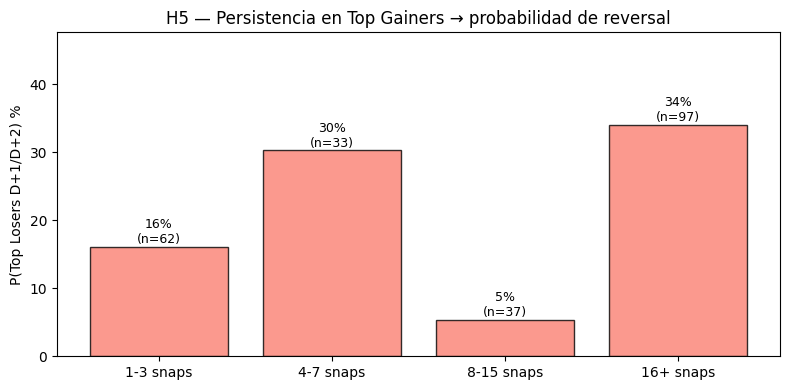

In [6]:
day_list = sorted(ALL_DAYS)
day_idx  = {d: i for i, d in enumerate(day_list)}
tl       = raw[raw['category'] == 'Top Losers'][['ticker','day']].drop_duplicates()
persist  = tg.groupby(['ticker','day'])['appearance_n'].max().reset_index(name='max_pers')

sat_rows = []
for _, r in persist.iterrows():
    i = day_idx.get(r['day'])
    if i is None: continue
    d1 = day_list[i+1] if i+1 < len(day_list) else None
    d2 = day_list[i+2] if i+2 < len(day_list) else None
    loser = (
        (d1 is not None and not tl[(tl['ticker']==r['ticker']) & (tl['day']==d1)].empty) or
        (d2 is not None and not tl[(tl['ticker']==r['ticker']) & (tl['day']==d2)].empty)
    )
    sat_rows.append({'ticker': r['ticker'], 'day': r['day'],
                     'max_pers': r['max_pers'], 'loser_next2': loser})

sat_df = pd.DataFrame(sat_rows)
print('H5 — P(Top Losers D+1/D+2) segun persistencia en Top Gainers:')
print()

buckets = [(1,3,'1-3 snaps'),(4,7,'4-7 snaps'),(8,15,'8-15 snaps'),(16,999,'16+ snaps')]
xs, ys, ns = [], [], []
for lo, hi, label in buckets:
    sub = sat_df[(sat_df['max_pers'] >= lo) & (sat_df['max_pers'] <= hi)]
    if len(sub) == 0: continue
    p = sub['loser_next2'].mean()
    print(f'  {label:<15}  n={len(sub):>4}  P(reversal)={p:.0%}')
    xs.append(label); ys.append(p*100); ns.append(len(sub))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xs, ys, color='salmon', alpha=0.8, edgecolor='black')
for i, (y, n) in enumerate(zip(ys, ns)):
    ax.text(i, y + 0.5, f'{y:.0f}%\n(n={n})', ha='center', fontsize=9)
ax.set_ylabel('P(Top Losers D+1/D+2) %')
ax.set_title('H5 — Persistencia en Top Gainers → probabilidad de reversal')
ax.set_ylim(0, max(ys) * 1.4)
plt.tight_layout(); plt.show()

## 6. Visualización: dinámica del tablero

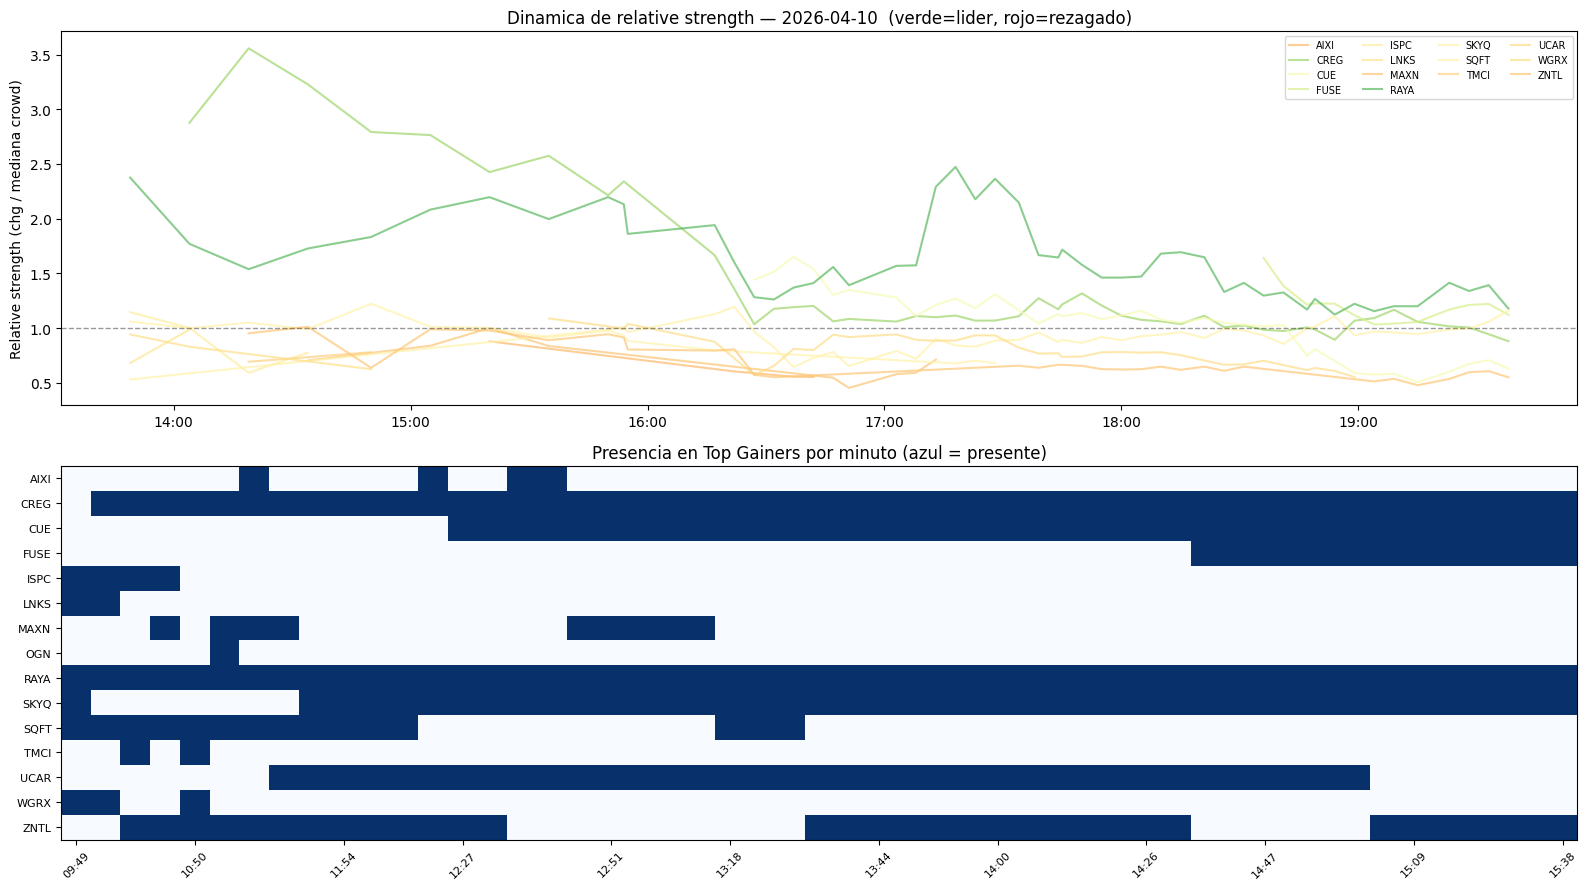

Dia: 2026-04-10 | 15 tickers | 51 polls


In [7]:
day_plot = events.groupby('day').size().idxmax()
day_tg   = tg[tg['day'] == day_plot].copy()
polls    = sorted(day_tg['ts_min'].unique())
tickers  = sorted(day_tg['ticker'].unique())

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Panel 1: relative strength a lo largo del dia
ax = axes[0]
cmap = plt.cm.RdYlGn
for ticker in tickers:
    sub = day_tg[day_tg['ticker'] == ticker].sort_values('ts_min')
    if len(sub) < 2: continue
    color = cmap(min(sub['rel_strength'].mean() / 2.0, 1.0))
    ax.plot(sub['ts_min'], sub['rel_strength'], alpha=0.7, lw=1.5, color=color, label=ticker)
ax.axhline(1.0, color='black', lw=1, linestyle='--', alpha=0.4)
ax.set_ylabel('Relative strength (chg / mediana crowd)')
ax.set_title(f'Dinamica de relative strength — {day_plot}  (verde=lider, rojo=rezagado)')
ax.legend(fontsize=7, loc='upper right', ncol=4)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))

# Panel 2: presencia binaria (heatmap)
ax = axes[1]
presence = pd.DataFrame(0, index=tickers, columns=range(len(polls)))
poll_idx = {p: i for i, p in enumerate(polls)}
for _, row in day_tg.iterrows():
    if row['ticker'] in tickers and row['ts_min'] in poll_idx:
        presence.loc[row['ticker'], poll_idx[row['ts_min']]] = 1

ax.imshow(presence.values, aspect='auto', cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax.set_yticks(range(len(tickers)))
ax.set_yticklabels(tickers, fontsize=8)
tick_idx = np.linspace(0, len(polls)-1, min(12, len(polls)), dtype=int)
ax.set_xticks(tick_idx)
ax.set_xticklabels([polls[i].strftime('%H:%M') for i in tick_idx], rotation=45, fontsize=8)
ax.set_title('Presencia en Top Gainers por minuto (azul = presente)')

plt.tight_layout()
plt.show()
print(f'Dia: {day_plot} | {len(tickers)} tickers | {len(polls)} polls')

## 7. Resumen y conclusiones

In [8]:
print('=' * 70)
print('CONCLUSIONES — juego de atención Finviz')
print('=' * 70)
print()
print('HALLAZGOS EN VALIDACIÓN (Apr 10-17, n=39):')
print()

segments = [
    ('Baseline sin filtro',                  validate['ret']),
    ('RS rezagado < 0.8x  (contrarian)',     validate[validate['rel_strength'] < 0.8]['ret']),
    ('Solo Top Gainers att=1',               validate[validate['attention_score'] == 1]['ret']),
    ('Schelling att >= 3',                   validate[validate['attention_score'] >= 3]['ret']),
    ('Lider rank=1',                         validate[validate['chg_rank'] == 1]['ret']),
    ('mso < 30min',                          validate[validate['mso'] < 30]['ret']),
    ('mso >= 60min',                         validate[validate['mso'] >= 60]['ret']),
    ('RS<0.8 + att=1 + mso<60',             validate[
        (validate['rel_strength'] < 0.8) &
        (validate['attention_score'] == 1) &
        (validate['mso'] < 60)
    ]['ret']),
]
for label, s in segments:
    show(s, label)

print()
print('─' * 70)
print('INTERPRETACION:')
print()
print('1. RS rezagado (< 0.8x mediana): el ticker mas debil del crowd pero')
print('   aun presente en Top Gainers muestra el mejor forward return.')
print('   Logica: capital de participantes no ha llegado todavia → recorrido.')
print()
print('2. Schelling >=3 categorias: trampa de atencion.')
print('   Maxima visibilidad = el movimiento ya esta hecho. Entrar = tarde.')
print()
print('3. Lider rank=1: el ticker mas visible es el mas peligroso.')
print('   EV negativo: mas vendedores potenciales que compradores nuevos.')
print()
print('4. Saturacion: P(reversal D+1/D+2) sube de 18% a 36% cuando')
print('   el ticker lleva 4-7 apariciones. Señal de salida para PBT1.')
print()
print('─' * 70)
print('REGLA CANDIDATA (requiere mas datos para confirmar):')
print()
print('  ENTRAR: RS < 0.8x mediana del crowd')
print('          + attention_score = 1 (nadie mas lo ve)')
print('          + mso < 60min')
print()
print('  EVITAR: rank=1 o attention>=3 (demasiado visible)')
print('          max_persistence >= 4 en el mismo dia')
print()
print('  LIMITACION: n=39 en validacion. Para p<0.05 con potencia 80%')
print('  sobre EV~1.2% necesitas ~80 observaciones mas (~20 dias).')

CONCLUSIONES — juego de atención Finviz

HALLAZGOS EN VALIDACIÓN (Apr 10-17, n=39):

  Baseline sin filtro                           n= 39  WR=41%  EV=-0.53%  PF=0.77  p=0.541  
  RS rezagado < 0.8x  (contrarian)              n= 15  WR=53%  EV=+1.24%  PF=1.80  p=0.491  
  Solo Top Gainers att=1                        n= 14  WR=43%  EV=+0.54%  PF=1.28  p=0.771  
  Schelling att >= 3                            n= 12  WR=50%  EV=-0.99%  PF=0.50  p=0.374  
  Lider rank=1                                  n=  5  WR=20%  EV=-3.32%  PF=0.08  p=0.061 ~
  mso < 30min                                   n= 28  WR=39%  EV=-1.05%  PF=0.55  p=0.206  
  mso >= 60min                                  n=  9  WR=44%  EV=+1.45%  PF=1.77  p=0.603  
  RS<0.8 + att=1 + mso<60                       n=  7  WR=57%  EV=-0.37%  PF=0.73  p=0.759  

──────────────────────────────────────────────────────────────────────
INTERPRETACION:

1. RS rezagado (< 0.8x mediana): el ticker mas debil del crowd pero
   aun present

## 8. Bar Structure — Entry & Exit signals

Analizar la estructura de las barras en el momento de entrada para encontrar filtros y reglas de salida que superen el trailing stop fijo del 5%.

**Hipótesis**:
- Barra de entrada verde (close > open) con close en parte alta del rango → momentum continua
- Barra roja o close en parte baja → entrada en caída, peor resultado
- Salida estructural: bar cierra por debajo del low anterior → momentum roto

In [9]:

def get_entry_bar_features(ticker, day, sig_ts, n_bars=10):
    """
    Extrae features de la barra de entrada y las siguientes n_bars barras.
    Retorna dict o None si no hay datos.
    """
    db = bars_idx.get(ticker, day)
    if db is None:
        return None
    future = db[db['bar_ts'] > sig_ts].sort_values('bar_ts').reset_index(drop=True)
    if future.empty:
        return None

    b0 = future.iloc[0]
    ep = float(b0['open'])
    if ep <= 0:
        return None

    b0_range = float(b0['high']) - float(b0['low'])
    b0_green = float(b0['close']) >= float(b0['open'])
    b0_close_pos = (float(b0['close']) - float(b0['low'])) / b0_range if b0_range > 0 else 0.5
    b0_range_pct  = b0_range / ep
    b0_body_pct   = abs(float(b0['close']) - float(b0['open'])) / ep

    window = future.iloc[:n_bars]
    highs  = window['high'].astype(float).values
    lows   = window['low'].astype(float).values
    closes = window['close'].astype(float).values

    mfe_5    = (highs[:5].max()  - ep) / ep if len(highs) >= 1 else None
    mae_5    = (lows[:5].min()   - ep) / ep if len(lows)  >= 1 else None
    hold_5   = (closes[min(4, len(closes)-1)] - ep) / ep

    # Salida estructural: primera barra que cierra debajo del low de la barra anterior
    struct_exit_bar = None
    struct_exit_ret = None
    for i in range(1, len(window)):
        if float(window.iloc[i]['close']) < float(window.iloc[i-1]['low']):
            struct_exit_ret = (float(window.iloc[i]['close']) - ep) / ep - SLIPPAGE
            struct_exit_bar = i
            break
    if struct_exit_ret is None:
        # no salida estructural → salida al cierre de la última barra de la ventana
        struct_exit_ret = (closes[-1] - ep) / ep - SLIPPAGE
        struct_exit_bar = len(window) - 1

    # Trail 5% over n_bars ventana
    trail_exit_ret = None
    peak = ep
    for _, bar in window.iterrows():
        peak = max(peak, float(bar['high']))
        if float(bar['low']) <= peak * (1 - 5/100):
            trail_exit_ret = (peak * 0.95 - ep) / ep - SLIPPAGE
            break
    if trail_exit_ret is None:
        trail_exit_ret = (closes[-1] - ep) / ep - SLIPPAGE

    return {
        'b0_green'      : b0_green,
        'b0_close_pos'  : b0_close_pos,
        'b0_range_pct'  : b0_range_pct,
        'b0_body_pct'   : b0_body_pct,
        'mfe_5'         : mfe_5,
        'mae_5'         : mae_5,
        'hold_5'        : hold_5,
        'struct_exit_ret': struct_exit_ret,
        'struct_exit_bar': struct_exit_bar,
        'trail_exit_ret' : trail_exit_ret,
        'entry_price'   : ep,
        'n_bars_avail'  : len(window),
    }


# Enriquecer eventos con bar features
bar_feat_rows = []
for _, ev in events.iterrows():
    feat = get_entry_bar_features(ev['ticker'], ev['day'], ev['ts'], n_bars=15)
    if feat is None:
        continue
    row = ev.to_dict()
    row.update(feat)
    bar_feat_rows.append(row)

bf = pd.DataFrame(bar_feat_rows)
bf_val = bf[bf['split'] == 'validate']

print(f'Eventos con bar features: {len(bf)}  (validate={len(bf_val)})')
print(f'b0_green rate validate: {bf_val["b0_green"].mean():.0%}')
print(f'b0_close_pos median: {bf_val["b0_close_pos"].median():.2f}')
print(f'struct_exit_bar median: {bf_val["struct_exit_bar"].median():.0f} bars')


Eventos con bar features: 49  (validate=39)
b0_green rate validate: 59%
b0_close_pos median: 0.50
struct_exit_bar median: 3 bars


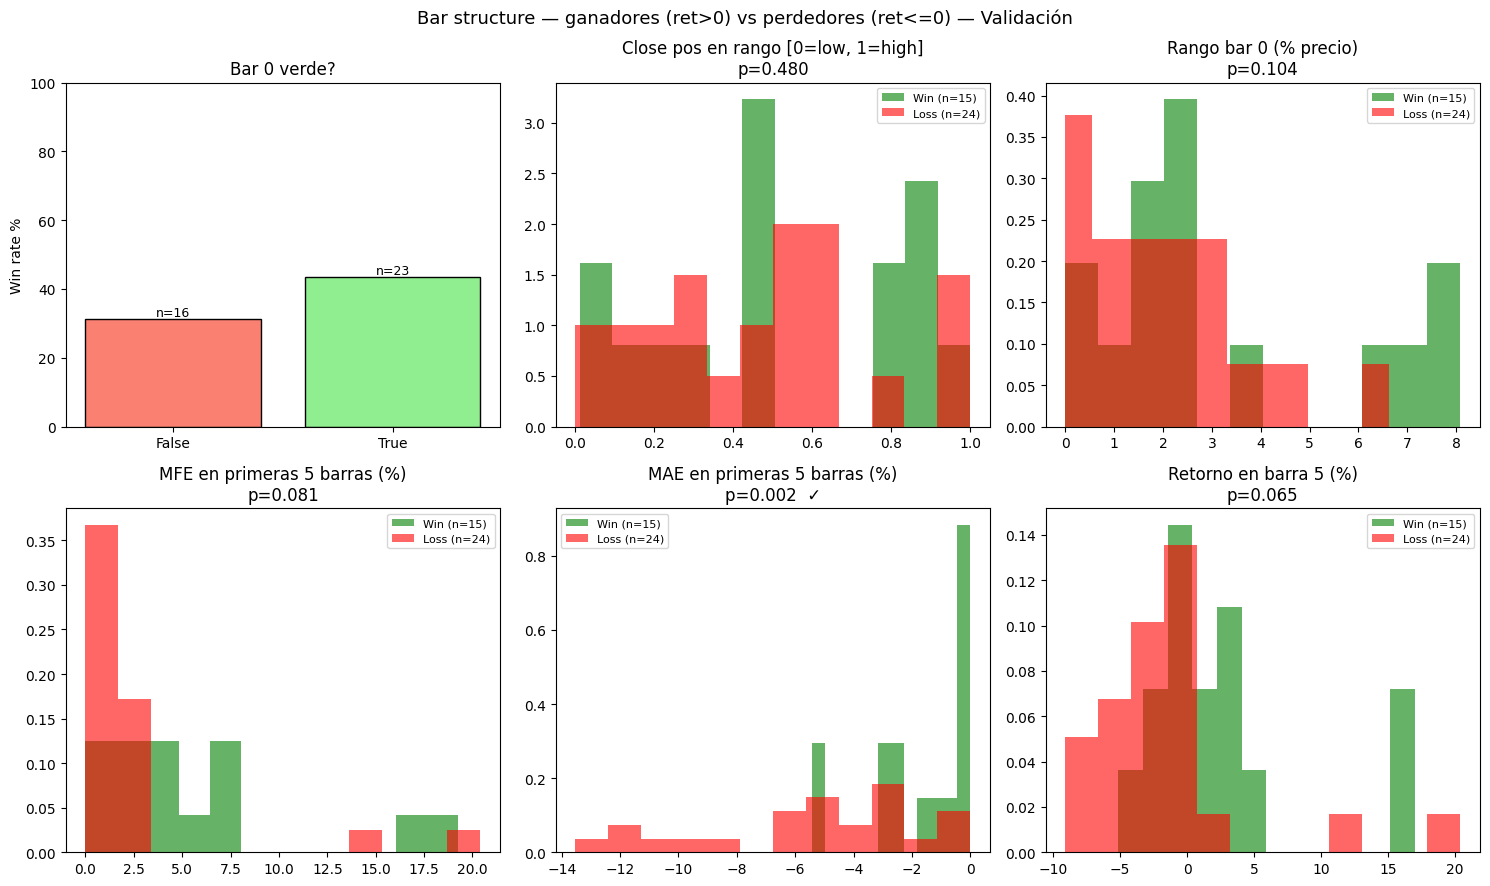


── Win rate por cuartil de b0_close_pos (posicion del cierre en el rango) ──
  Q1
(bajo)   n= 10  WR=40%  EV=+0.05%
  Q2          n= 15  WR=33%  EV=-1.22%
  Q3          n=  4  WR=0%  EV=-4.08%
  Q4
(alto)   n= 10  WR=60%  EV=-0.00%


In [10]:

# ── Comparacion ganadores vs perdedores en bar features ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Bar structure — ganadores (ret>0) vs perdedores (ret<=0) — Validación', fontsize=13)

bv = bf_val.copy()
bv['winner'] = bv['trail_exit_ret'] > 0

features = [
    ('b0_green',     'Bar 0 verde?',          False),
    ('b0_close_pos', 'Close pos en rango [0=low, 1=high]', True),
    ('b0_range_pct', 'Rango bar 0 (% precio)', True),
    ('mfe_5',        'MFE en primeras 5 barras (%)', True),
    ('mae_5',        'MAE en primeras 5 barras (%)', True),
    ('hold_5',       'Retorno en barra 5 (%)', True),
]

for ax, (feat, title, is_num) in zip(axes.flat, features):
    w = bv[bv['winner']][feat].dropna()
    l = bv[~bv['winner']][feat].dropna()
    if is_num:
        ax.hist(w * 100 if 'pct' in feat or feat in ('mfe_5','mae_5','hold_5') else w,
                bins=12, alpha=0.6, color='green', label=f'Win (n={len(w)})', density=True)
        ax.hist(l * 100 if 'pct' in feat or feat in ('mfe_5','mae_5','hold_5') else l,
                bins=12, alpha=0.6, color='red', label=f'Loss (n={len(l)})', density=True)
        _, pval = scipy_stats.ttest_ind(w, l)
        ax.set_title(f'{title}\np={pval:.3f}{"  ✓" if pval < 0.05 else ""}')
        ax.legend(fontsize=8)
    else:
        cats = ['False', 'True']
        total = {'False': len(bv[bv[feat] == False]), 'True': len(bv[bv[feat] == True])}
        win_r = {str(v): (bv[bv[feat] == v]['winner'].mean() if total[str(v)] > 0 else 0)
                 for v in [False, True]}
        counts = [total[c] for c in cats]
        rates  = [win_r[c] * 100 for c in cats]
        bars_plt = ax.bar(cats, rates, color=['salmon', 'lightgreen'], edgecolor='black')
        for bar_, cnt in zip(bars_plt, counts):
            ax.text(bar_.get_x() + bar_.get_width()/2, bar_.get_height() + 1,
                    f'n={cnt}', ha='center', fontsize=9)
        ax.set_ylabel('Win rate %')
        ax.set_title(title)
        ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Tabla resumen por cuartil de close_pos
print('\n── Win rate por cuartil de b0_close_pos (posicion del cierre en el rango) ──')
bv['close_pos_q'] = pd.qcut(bv['b0_close_pos'], q=4, labels=['Q1\n(bajo)','Q2','Q3','Q4\n(alto)'], duplicates='drop')
for q, grp in bv.groupby('close_pos_q', observed=True):
    wr  = grp['trail_exit_ret'].gt(0).mean()
    ev  = grp['trail_exit_ret'].mean() * 100
    print(f'  {str(q):<10}  n={len(grp):>3}  WR={wr:.0%}  EV={ev:+.2f}%')


═════════════════════════════════════════════════════════════════
COMPARACION DE METODOS DE SALIDA — Validación
═════════════════════════════════════════════════════════════════

SIN FILTRO DE ENTRADA:
  Trail 5% (15 barras)                          n= 39  WR=38%  EV=-0.87%  PF=0.62  p=0.257
  Salida estructural (bar < prior low)          n= 39  WR=26%  EV=-0.78%  PF=0.67  p=0.483

CON FILTRO b0_close_pos >= 0.5 (close en mitad alta del rango):
  Trail 5% — close_pos >= 0.5                   n= 20  WR=40%  EV=-0.89%  PF=0.56  p=0.379
  Salida estructural — close_pos >= 0.5         n= 20  WR=25%  EV=-2.16%  PF=0.25  p=0.145

RECHAZADOS (close_pos < 0.5):
  Trail 5% — close_pos < 0.5                    n= 19  WR=37%  EV=-0.86%  PF=0.68  p=0.480
  Salida estructural — close_pos < 0.5          n= 19  WR=26%  EV=+0.67%  PF=1.36  p=0.697

COMBO RS<0.8 + close_pos>=0.5:
  Trail 5%                                      n= 11  WR=45%  EV=+0.35%  PF=1.24  p=0.831
  Salida estructural             

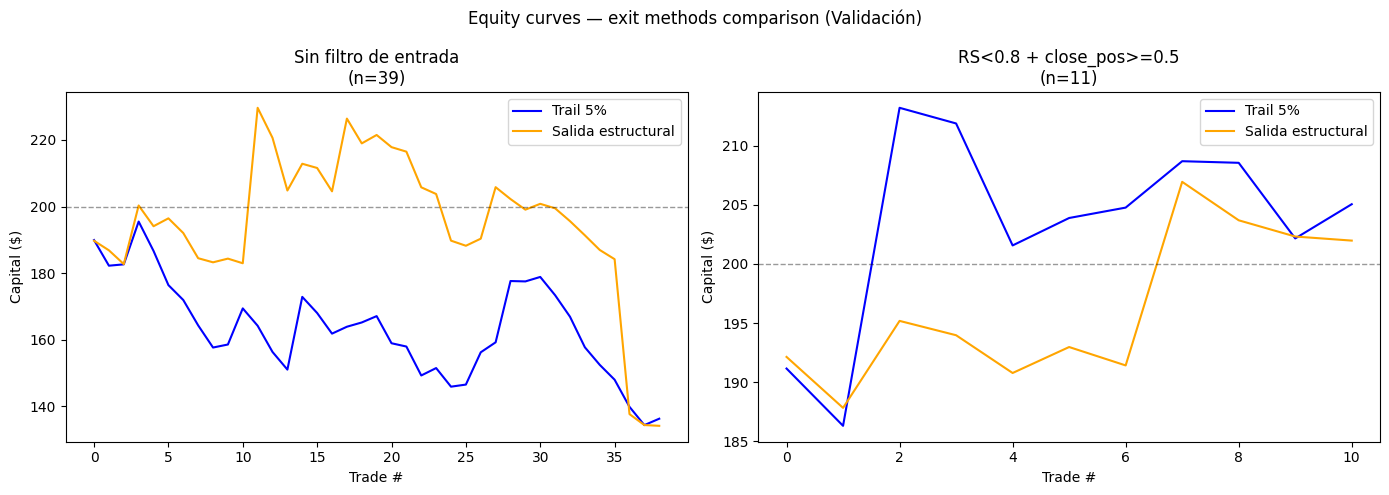

In [11]:

# ── Comparar exit methods: trailing 5% vs salida estructural ─────────────
print('═' * 65)
print('COMPARACION DE METODOS DE SALIDA — Validación')
print('═' * 65)
print()

def exit_summary(s, label):
    s = s.dropna()
    if len(s) == 0: return
    wr  = (s > 0).mean()
    ev  = s.mean() * 100
    wins = s[s > 0]; loss = s[s < 0]
    pf  = wins.sum() / abs(loss.sum()) if len(loss) > 0 else np.inf
    _, p = scipy_stats.ttest_1samp(s, 0)
    print(f'  {label:<45} n={len(s):>3}  WR={wr:.0%}  EV={ev:+.2f}%  PF={pf:.2f}  p={p:.3f}')

print('SIN FILTRO DE ENTRADA:')
exit_summary(bf_val['trail_exit_ret'],  'Trail 5% (15 barras)')
exit_summary(bf_val['struct_exit_ret'], 'Salida estructural (bar < prior low)')
print()

# Filtro: barra de entrada en top 50% del rango (close_pos >= 0.5)
strong_entry = bf_val[bf_val['b0_close_pos'] >= 0.5]
weak_entry   = bf_val[bf_val['b0_close_pos'] <  0.5]
print('CON FILTRO b0_close_pos >= 0.5 (close en mitad alta del rango):')
exit_summary(strong_entry['trail_exit_ret'],  'Trail 5% — close_pos >= 0.5')
exit_summary(strong_entry['struct_exit_ret'], 'Salida estructural — close_pos >= 0.5')
print()
print('RECHAZADOS (close_pos < 0.5):')
exit_summary(weak_entry['trail_exit_ret'],    'Trail 5% — close_pos < 0.5')
exit_summary(weak_entry['struct_exit_ret'],   'Salida estructural — close_pos < 0.5')
print()

# Combinado: RS<0.8 + close_pos>=0.5
combo = bf_val[(bf_val['rel_strength'] < 0.8) & (bf_val['b0_close_pos'] >= 0.5)]
print('COMBO RS<0.8 + close_pos>=0.5:')
exit_summary(combo['trail_exit_ret'],  'Trail 5%')
exit_summary(combo['struct_exit_ret'], 'Salida estructural')
print()

# Equity curve comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Equity curves — exit methods comparison (Validación)', fontsize=12)

for ax, subset, title in [
    (axes[0], bf_val, 'Sin filtro de entrada'),
    (axes[1], combo,  'RS<0.8 + close_pos>=0.5'),
]:
    if len(subset) == 0:
        ax.set_title(f'{title} — sin datos')
        continue
    sub_sorted = subset.sort_values('day')
    cap = 200
    for col, label, color in [
        ('trail_exit_ret',  'Trail 5%',          'blue'),
        ('struct_exit_ret', 'Salida estructural', 'orange'),
    ]:
        s = sub_sorted[col].dropna()
        equity = (1 + s).cumprod() * cap
        ax.plot(range(len(equity)), equity.values, label=label, color=color)
    ax.axhline(cap, color='black', lw=1, linestyle='--', alpha=0.4)
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Capital ($)')
    ax.set_title(f'{title}\n(n={len(subset)})')
    ax.legend()

plt.tight_layout()
plt.show()


In [12]:

# ── Trade-level detail — combo filter ────────────────────────────────────
print('TRADES INDIVIDUALES — combo RS<0.8 + close_pos>=0.5 (validación)')
print(f'{"Day":<12} {"Ticker":<8} {"MSO":>5} {"RS":>6} {"ClsPos":>7} {"Trail5%":>8} {"Struct":>8} {"b0G":>5}')
print('─' * 70)

for _, r in combo.sort_values(['day','ts']).iterrows():
    trail = r['trail_exit_ret'] * 100 if pd.notna(r['trail_exit_ret']) else float('nan')
    struct = r['struct_exit_ret'] * 100 if pd.notna(r['struct_exit_ret']) else float('nan')
    b0g = 'Y' if r['b0_green'] else 'N'
    print(f'{r["day"]:<12} {r["ticker"]:<8} {int(r["mso"]):>5} '
          f'{r["rel_strength"]:>6.2f} {r["b0_close_pos"]:>7.2f} '
          f'{trail:>7.1f}% {struct:>7.1f}%  {b0g}')

print()
print(f'Total trades: {len(combo)}')
trail_s = combo['trail_exit_ret'].dropna()
struct_s = combo['struct_exit_ret'].dropna()
print(f'Trail  5%: EV={trail_s.mean()*100:+.2f}%  WR={trail_s.gt(0).mean():.0%}  '
      f'PF={trail_s[trail_s>0].sum()/abs(trail_s[trail_s<0].sum()):.2f}')
print(f'Structural: EV={struct_s.mean()*100:+.2f}%  WR={struct_s.gt(0).mean():.0%}  '
      f'PF={struct_s[struct_s>0].sum()/abs(struct_s[struct_s<0].sum()):.2f}')


TRADES INDIVIDUALES — combo RS<0.8 + close_pos>=0.5 (validación)
Day          Ticker     MSO     RS  ClsPos  Trail5%   Struct   b0G
──────────────────────────────────────────────────────────────────────
2026-04-10   LNKS        19   0.68    0.63    -4.4%    -3.9%  N
2026-04-10   SKYQ        19   0.53    1.00    -2.5%    -2.2%  Y
2026-04-14   AVNS        15   0.76    1.00    -0.6%    -0.6%  Y
2026-04-14   HUBC        15   0.46    0.59    -4.9%    -1.6%  Y
2026-04-14   AFJK        61   0.51    0.50    14.5%     3.9%  Y
2026-04-14   MGRT       229   0.76    0.50     1.2%     1.2%  Y
2026-04-15   BNRG        29   0.55    1.00     0.4%    -0.8%  Y
2026-04-15   XNDU       130   0.68    0.91     1.9%     8.1%  Y
2026-04-16   XNDU        22   0.45    0.50    -3.1%    -0.7%  Y
2026-04-16   RECT        38   0.41    0.98    -0.1%    -1.6%  Y
2026-04-17   CRML        17   0.76    0.88     1.4%    -0.2%  Y

Total trades: 11
Trail  5%: EV=+0.35%  WR=45%  PF=1.24
Structural: EV=+0.14%  WR=27%  PF=1.1